# Projeto 4 — Álgebra Linear Numérica


---

## Questão 1 — Cálculo dos Refletores de Householder

---
## Item (a) — Derivação de $v$ e $\beta$

**Enunciado:** Mostrar que, para $Q_v x = \|x\|\, e_1$, temos
$$v = x - \|x\|\, e_1, \qquad
\beta = \frac{1}{\|x\|(\|x\| - x_1)}
     = \frac{\|x\| + x_1}{\|x\|(\|x\|^2 - x_1^2)}
     = \frac{\|x\| + x_1}{\|x\| \cdot \|y\|^2},$$
onde $y = (x_2, \ldots, x_n)$.

### Solução

Queremos $Q_v x = \|x\|\,e_1$, ou seja:
$$(I - \beta v v^*) x = \|x\|\, e_1.$$
 
Um refletor de Householder reflete $x$ em $\|x\|e_1$, ou seja, o hiperplano de reflexão é a bissetriz entre $x$ e $\|x\|e_1$. O vetor normal a esse hiperplano é:
$$v = x - \|x\|\, e_1.$$
 
Para que $(I - \beta v v^*) x = \|x\|\, e_1$, precisamos:
$$x - \beta (v^* x)\, v = \|x\|\, e_1.$$

Como $v = x - \|x\|\, e_1$, temos:
$$v^* x = (x - \|x\|\, e_1)^* x = \|x\|^2 - \|x\|\, x_1.$$

Substituindo:
$$x - \beta(\|x\|^2 - \|x\| x_1)\,v = \|x\|\, e_1 \implies \beta(\|x\|^2 - \|x\| x_1)\,v = v.$$

Portanto, desde que $v \neq 0$:
$$\boxed{\beta = \frac{1}{\|x\|^2 - \|x\| x_1} = \frac{1}{\|x\|(\|x\| - x_1)}}.$$

Multiplicando numerador e denominador por $(\|x\| + x_1)$:
$$\beta = \frac{\|x\| + x_1}{\|x\|(\|x\|^2 - x_1^2)}.$$

Como $\|x\|^2 - x_1^2 = x_2^2 + \cdots + x_n^2 = \|y\|^2$ (onde $y = (x_2, \ldots, x_n)$):
$$\boxed{\beta = \frac{\|x\| + x_1}{\|x\| \cdot \|y\|^2}}.$$

**Verificação de ortogonalidade de $Q_v$:**  
Note que $\|v\|^2 = v^* v = \|x\|^2 - 2\|x\| x_1 + \|x\|^2 = 2(\|x\|^2 - \|x\| x_1)$, então $\beta = 2/\|v\|^2$, que é exatamente a condição para que $Q_v = I - \beta vv^*$ seja ortogonal ($Q_v^* = Q_v^{-1} = Q_v$). $\blacksquare$

---
## Item (b) — Cancelamento Numérico

**Enunciado:** Verificar que, dependendo do sinal de $x_1$, uma das fórmulas para $\beta$ não está sujeita a cancelamento numérico.

### Solução

As duas formas candidatas para o denominador de $\beta$ são:
- **Forma 1:** $\|x\|(\|x\| - x_1)$
- **Forma 2:** $\|x\|(\|x\| + x_1)$ (no denominador da expressão $\beta = (\|x\|+x_1)/(\|x\|\|y\|^2)$, veja a relação com a Forma 1)

O problema é que $v_1 = x_1 - \|x\|$ pode sofrer cancelamento:

| Sinal de $x_1$ | $v_1 = x_1 - \|x\|$ | Problema |
|:---:|:---:|:---:|
| $x_1 > 0$ | $x_1 - \|x\| \approx 0$ se $x \approx \|x\|e_1$ | **Cancelamento em $v_1$** |
| $x_1 < 0$ | $x_1 - \|x\| \approx 2x_1$, sem cancelamento | Seguro |

Para o escalar $\beta$, vejamos a fórmula $\beta = 1/(\|x\|(\|x\| - x_1))$:

- Se $x_1 > 0$: o termo $\|x\| - x_1 \approx 0$ quando $x \approx \|x\|e_1$, causando cancelamento no denominador.
- Se $x_1 < 0$: $\|x\| - x_1 = \|x\| + |x_1| > \|x\|$, não há cancelamento.

A fórmula alternativa $\beta = (\|x\| + x_1)/(\|x\| \cdot \|y\|^2)$ funciona quando $x_1 > 0$ (pois $\|x\| + x_1 \geq \|x\|$), mas falha quando $x_1 < 0$.

**Estratégia numericamente estável:** escolher o sinal de $\|x\|$ **oposto** ao de $x_1$, ou seja, usar $\sigma = -\text{sign}(x_1)$ e definir:
$$v_1 = x_1 + \sigma\|x\|, \quad \beta = \frac{-\sigma}{\|x\| v_1} = \frac{1}{|v_1| \cdot \|x\|}, \quad Q_v x = -\sigma\|x\|\,e_1.$$

Com essa escolha, $v_1 = x_1 + \sigma \|x\|$ nunca é pequeno (pois $x_1$ e $\sigma\|x\|$ têm o mesmo sinal), eliminando o cancelamento.

> **Obs.:** O enunciado pede que refletimos em $+\|x\|e_1$ (diagonal positiva em $R$). Para $x_1 > 0$, isso equivale a usar a fórmula $\beta = (\|x\|+x_1)/(\|x\| \|y\|^2)$, que evita cancelamento neste caso.

---
## Item (c) — Implementação: `reflector(x)`

A função recebe um vetor $x$ e retorna $(v, \beta)$ tal que $Q_v x = \|x\|\,e_1$ com diagonal positiva (i.e., reflete sempre em $+\|x\|e_1$, forçando $v_1 \leq 0$).

In [2]:
using LinearAlgebra

function reflector(x)
    n = length(x)
    nrmx = norm(x)           # ||x||
    
    v = copy(x)              # v = x (cópia, para não modificar x)
    v[1] -= nrmx             # v_1 = x_1 - ||x||  ->  v = x - ||x||e_1
    
    # Cálculo de beta evitando cancelamento numérico:
    # v_1 = x_1 - ||x||. Se x_1 > 0, há cancelamento; usamos a identidade
    # (||x|| - x_1)(||x|| + x_1) = ||x||^2 - (x_1)^2 = ||y||^2
    if x[1] > 0
        # Beta = (||x|| + x_1) / (||x|| * ||y||^2)
        # equivalente a beta = -1 / (nrmx * v_1)  mas numericamente melhor
        nrmy2 = sum(x[i]^2 for i in 2:n)
        beta = (nrmx + x[1]) / (nrmx * nrmy2)
    else
        # beta = 1 / (||x|| * (||x|| - x_1)) = 1 / (nrmx * (-v_1))
        beta = one(eltype(v)) / (nrmx * (-v[1]))   # -v_1 = ||x|| - x_1 > 0
    end
    
    return v, beta
end

reflector (generic function with 1 method)

---
## Item (d) — Condicionamento de $v$ em relação a $x$

**Enunciado:** Mostrar que a derivada de $v$ em relação a $x$ é $J = I - e_1 x^* / \|x\|$ e que o número de condicionamento absoluto de $v$ em relação a $x$ é $\leq 2$.

### Solução

**Derivada de $v$:** Temos $v(x) = x - \|x\|\,e_1$. A derivada da norma $\|x\| = (x^*x)^{1/2}$ em relação a $x$ é $x^*/\|x\|$. Aplicando isso, obtemos diretamente a matriz Jacobiana:
$$J = \frac{\partial v}{\partial x} = I - e_1 \frac{x^*}{\|x\|}.$$

**Número de condicionamento absoluto:** O número de condicionamento absoluto de $v$ em relação a $x$ é limitado pela norma-2 da Jacobiana, ou seja, $\|J\|_2$.

Seja $\hat{x} = x/\|x\|$ o vetor unitário na direção de $x$. Podemos reescrever $J$ como uma perturbação de posto 1 da matriz identidade:
$$J = I - e_1 \hat{x}^*.$$

Para encontrar o limite superior de $\|J\|_2$, aplicamos a desigualdade triangular para normas matriciais:
$$\|J\|_2 = \|I - e_1 \hat{x}^*\|_2 \leq \|I\|_2 + \|e_1 \hat{x}^*\|_2.$$

Sabemos que a norma-2 da matriz identidade é $\|I\|_2 = 1$. Além disso, para a matriz de posto 1 $e_1 \hat{x}^*$, sua norma-2 é exatamente o produto das normas-2 dos vetores que a compõem:
$$\|e_1 \hat{x}^*\|_2 = \|e_1\|_2 \|\hat{x}\|_2 = 1 \cdot 1 = 1.$$

Substituindo esses valores na desigualdade:
$$\boxed{\|J\|_2 \leq 1 + 1 = 2.}$$

Portanto, o número de condicionamento absoluto é menor ou igual a 2, provando que $v$ é um mapeamento bem condicionado em relação a $x$. $\blacksquare$

---
## Item (e) — Estabilidade: testes Float64 e Float32

Verificamos que `reflector(x)` retorna resultados no mesmo tipo de `x`, e testamos a precisão da reflexão $Q_v x \approx \|x\| e_1$ em ambos os tipos.

In [3]:
# Função auxiliar para aplicar o refletor Q_v * x = (I - beta*v*v') * x
apply_reflector_vec(v, b, x) = x - b * (v' * x) * v

# --- Teste com vetor genérico ---
println("=== Vetor genérico ===")
x64 = [3.0, 4.0, 0.0]          # Float64
x32 = Float32[3.0, 4.0, 0.0]   # Float32

v64, b64 = reflector(x64)
v32, b32 = reflector(x32)

println("Float64: typeof(v) = ", typeof(v64), ", typeof(b) = ", typeof(b64))
println("Float32: typeof(v) = ", typeof(v32), ", typeof(b) = ", typeof(b32))

Qx64 = apply_reflector_vec(v64, b64, x64)
Qx32 = apply_reflector_vec(v32, b32, x32)

nrmx64 = norm(x64)
nrmx32 = norm(x32)

println("\nFloat64: Q_v*x = ", Qx64)
println("Esperado:        [", nrmx64, ", 0, 0]")
println("Erro (Float64):  ", norm(Qx64 - [nrmx64, 0, 0]))

println("\nFloat32: Q_v*x = ", Qx32)
println("Esperado:        [", nrmx32, ", 0, 0]")
println("Erro (Float32):  ", norm(Qx32 - [nrmx32, 0, 0]))

=== Vetor genérico ===
Float64: typeof(v) = Vector{Float64}, typeof(b) = Float64
Float32: typeof(v) = Vector{Float32}, typeof(b) = Float32

Float64: Q_v*x = [5.0, 0.0, 0.0]
Esperado:        [5.0, 0, 0]
Erro (Float64):  0.0

Float32: Q_v*x = Float32[5.0, 0.0, 0.0]
Esperado:        [5.0, 0, 0]
Erro (Float32):  0.0


In [4]:
# --- Teste com vetor quase alinhado com e_1 (caso delicado para cancelamento) ---
println("=== Vetor quase alinhado com e_1 (x_1 > 0, pequenas componentes) ===")
e64 = 1e-8
e32 = Float32(1e-4)  # Float32 tem menos precisão

x64_near = [1.0, e64, e64]
x32_near = Float32[1.0, e32, e32]

v64n, b64n = reflector(x64_near)
v32n, b32n = reflector(x32_near)

Qx64n = apply_reflector_vec(v64n, b64n, x64_near)
Qx32n = apply_reflector_vec(v32n, b32n, x32_near)

nrm64n = norm(x64_near)
nrm32n = norm(x32_near)

println("\nFloat64: Q_v*x = ", Qx64n)
println("Erro relativo (Float64): ", norm(Qx64n - [nrm64n, 0, 0]) / nrm64n)

println("\nFloat32: Q_v*x = ", Qx32n)
println("Erro relativo (Float32): ", norm(Qx32n - [nrm32n, 0, 0]) / nrm32n)

=== Vetor quase alinhado com e_1 (x_1 > 0, pequenas componentes) ===

Float64: Q_v*x = [1.0, -9.999999999999997e-9, -9.999999999999997e-9]
Erro relativo (Float64): 1.4142135623730945e-8

Float32: Q_v*x = Float32[1.0, -0.0001, -0.0001]
Erro relativo (Float32): 0.00014142135


In [5]:
# --- Teste com vetor com x_1 < 0, que é a fórmula alternativa ---
println("=== Vetor com x_1 < 0 ===")
x64_neg = [-3.0, 4.0, 0.0]
x32_neg = Float32[-3.0, 4.0, 0.0]

v64_neg, b64_neg = reflector(x64_neg)
v32_neg, b32_neg = reflector(x32_neg)

Qx64_neg = apply_reflector_vec(v64_neg, b64_neg, x64_neg)
Qx32_neg = apply_reflector_vec(v32_neg, b32_neg, x32_neg)

nrm64_neg = norm(x64_neg)
nrm32_neg = norm(x32_neg)

println("\nFloat64: Q_v*x = ", Qx64_neg, " | esperado: [", nrm64_neg, ", 0, 0]")
println("Erro relativo (Float64): ", norm(Qx64_neg - [nrm64_neg, 0, 0]) / nrm64_neg)

println("\nFloat32: Q_v*x = ", Qx32_neg, " | esperado: [", nrm32_neg, ", 0, 0]")
println("Erro relativo (Float32): ", norm(Qx32_neg - [nrm32_neg, 0, 0]) / nrm32_neg)

=== Vetor com x_1 < 0 ===

Float64: Q_v*x = [5.0, 0.0, 0.0] | esperado: [5.0, 0, 0]
Erro relativo (Float64): 0.0

Float32: Q_v*x = Float32[5.0, 0.0, 0.0] | esperado: [5.0, 0, 0]
Erro relativo (Float32): 0.0


---
## Item (f) — Função `calc_beta(v)` e comparação

Dados apenas $v = x - \|x\|e_1$, podemos recuperar $\beta$ sem precisar de $x$ explicitamente.

### Derivação

Sabemos que $\beta = 2/\|v\|^2$ (condição de ortogonalidade de $Q_v$). De fato:
$$\|v\|^2 = \|x - \|x\|e_1\|^2 = \|x\|^2 - 2\|x\|x_1 + \|x\|^2 = 2(\|x\|^2 - \|x\|x_1) = 2\|x\|(\|x\| - x_1).$$

Portanto:
$$\boxed{\beta = \frac{2}{\|v\|^2}}.$$

Esta fórmula é sempre válida (desde que $v \neq 0$) e não apresenta cancelamento numérico, pois $\|v\|^2 > 0$.

In [6]:
function calc_beta(v)
    return 2 / (v' * v)   # beta = 2 / ||v||²
end

calc_beta (generic function with 1 method)

In [7]:
# Comparação entre reflector(x) e calc_beta(v) usando o v retornado
println("=== Comparação reflector(x) vs calc_beta(v) ===")

test_cases = [
    ("Genérico Float64",      [3.0, 4.0, 0.0]),
    ("Genérico Float32",      Float32[3.0, 4.0, 0.0]),
    ("Quase e_1 Float64",      [1.0, 1e-8, 1e-8]),
    ("Quase e_1 Float32",      Float32[1.0, 1f-4, 1f-4]),
    ("x_1 < 0, Float64",       [-3.0, 4.0, 0.0]),
    ("x_1 < 0, Float32",       Float32[-3.0, 4.0, 0.0]),
]

for (name, x) in test_cases
    v, b_from_x = reflector(x)
    b_from_v    = calc_beta(v)
    
    # Erros de reflexão com cada beta
    err_x = norm(apply_reflector_vec(v, b_from_x, x) - [norm(x); zeros(eltype(x), length(x)-1)])
    err_v = norm(apply_reflector_vec(v, b_from_v, x) - [norm(x); zeros(eltype(x), length(x)-1)])
    
    println("\n[$name]")
    println("  beta (de reflector):  $b_from_x  | erro ||Q_v*x - ||x||e_1|| = $err_x")
    println("  beta (de calc_beta):  $b_from_v  | erro ||Q_v*x - ||x||e_1|| = $err_v")
end

=== Comparação reflector(x) vs calc_beta(v) ===

[Genérico Float64]
  beta (de reflector):  0.1  | erro ||Q_v*x - ||x||e_1|| = 0.0
  beta (de calc_beta):  0.1  | erro ||Q_v*x - ||x||e_1|| = 0.0

[Genérico Float32]
  beta (de reflector):  0.1  | erro ||Q_v*x - ||x||e_1|| = 0.0
  beta (de calc_beta):  0.1  | erro ||Q_v*x - ||x||e_1|| = 0.0

[Quase e_1 Float64]
  beta (de reflector):  9.999999999999998e15  | erro ||Q_v*x - ||x||e_1|| = 1.4142135623730945e-8
  beta (de calc_beta):  9.999999999999998e15  | erro ||Q_v*x - ||x||e_1|| = 1.4142135623730945e-8

[Quase e_1 Float32]
  beta (de reflector):  1.0000001e8  | erro ||Q_v*x - ||x||e_1|| = 0.00014142135
  beta (de calc_beta):  1.0000001e8  | erro ||Q_v*x - ||x||e_1|| = 0.00014142135

[x_1 < 0, Float64]
  beta (de reflector):  0.025  | erro ||Q_v*x - ||x||e_1|| = 0.0
  beta (de calc_beta):  0.025  | erro ||Q_v*x - ||x||e_1|| = 0.0

[x_1 < 0, Float32]
  beta (de reflector):  0.025  | erro ||Q_v*x - ||x||e_1|| = 0.0
  beta (de calc_beta):  0

**Observação:** Como esperado, os dois valores de $\beta$ são praticamente idênticos e os erros de reflexão são comparáveis. A fórmula $\beta = 2/\|v\|^2$ é simples e numericamente estável, pois evita qualquer cancelamento.

---
## Item (g) — Bônus: Mau condicionamento de $v_1$ e fórmula alternativa

### Análise do condicionamento de $v_1$

Temos $v_1 = x_1 - \|x\|$. Quando $x$ está quase alinhado com $e_1$ (i.e., $x \approx \|x\|e_1$, com $x_1 > 0$), temos $\|x\| \approx x_1$ e portanto $v_1 \approx 0$.

A derivada parcial de $v_1$ em relação a $x_1$ é:
$$\frac{\partial v_1}{\partial x_1} = 1 - \frac{x_1}{\|x\|} = 1 - \cos\theta,$$
onde $\theta$ é o ângulo entre $x$ e $e_1$. Quando $\theta \to 0$, $v_1 \to 0$ mas a derivada $\to 0$ também. O número de condicionamento relativo é:
$$\kappa_{\text{rel}}(v_1) = \left|\frac{\partial v_1}{\partial x_1} \cdot \frac{x_1}{v_1}\right| = \frac{(1 - x_1/\|x\|)\, x_1}{x_1 - \|x\|} = \frac{x_1/\|x\|(\|x\| - x_1)}{x_1 - \|x\|} = -\frac{x_1}{\|x\|}.$$

Para $x \approx \|x\|e_1$: $x_1/\|x\| \approx 1$, então $\kappa_{\text{rel}}(v_1) \approx 1$. Mas o problema é que $|v_1| \ll \|x\|$, então erros absolutos em $v_1$ são amplificados na divisão por $v_1$ ao calcular $\beta$.

### Fórmula alternativa para $v_1$

Inspirada na identidade $v_1 \cdot (x_1 + \|x\|) = x_1^2 - \|x\|^2 = -\|y\|^2$:
$$v_1 = x_1 - \|x\| = \frac{-\|y\|^2}{x_1 + \|x\|}.$$

Quando $x_1 > 0$, o denominador $x_1 + \|x\| \geq \|x\| > 0$ é estável. Esta fórmula não sofre cancelamento mesmo quando $x \approx \|x\|e_1$.

In [8]:
using Printf

# Comparação de v_1 calculado pelas duas fórmulas conforme x -> ||x||e_1
println("=== Condicionamento de v_1 pela fórmula direta e pela fórmula alternativa ===")
println("x = [1-e, e/sqrt(2), e/sqrt(2)]  para e -> 0")
println()
@printf "%-12s  %-20s  %-20s  %-15s\n" "e" "v_1 direto" "v_1 alternativo" "erro relativo"
println("-"^72)

for exp in 1:15
    e = 10.0^(-exp)
    x = [1 - e, e/sqrt(2), e/sqrt(2)]
    nrmx = norm(x)
    
    # Fórmula direta: v_1 = x_1 - ||x||
    v1_direto = x[1] - nrmx
    
    # Fórmula alternativa: v_1 = -||y||^2 / (x_1 + ||x||)
    nrmy2 = x[2]^2 + x[3]^2
    v1_alt  = -nrmy2 / (x[1] + nrmx)
    
    err_rel = abs(v1_direto - v1_alt) / abs(v1_alt)
    @printf "1e-%-8d  %-20.6e  %-20.6e  %-15.6e\n" exp v1_direto v1_alt err_rel
end

=== Condicionamento de v_1 pela fórmula direta e pela fórmula alternativa ===
x = [1-e, e/sqrt(2), e/sqrt(2)]  para e -> 0

e             v_1 direto            v_1 alternativo       erro relativo  
------------------------------------------------------------------------
1e-1         -5.538514e-03         -5.538514e-03         8.143486e-15   
1e-2         -5.050376e-05         -5.050376e-05         1.567146e-13   
1e-3         -5.005004e-07         -5.005004e-07         3.953022e-11   
1e-4         -5.000500e-09         -5.000500e-09         4.687194e-09   
1e-5         -5.000056e-11         -5.000050e-11         1.184884e-06   
1e-6         -5.000445e-13         -5.000005e-13         8.790049e-05   
1e-7         -4.996004e-15         -5.000001e-15         7.993778e-04   
1e-8         0.000000e+00          -5.000000e-17         1.000000e+00   
1e-9         0.000000e+00          -5.000000e-19         1.000000e+00   
1e-10        0.000000e+00          -5.000000e-21         1.000000e+00   

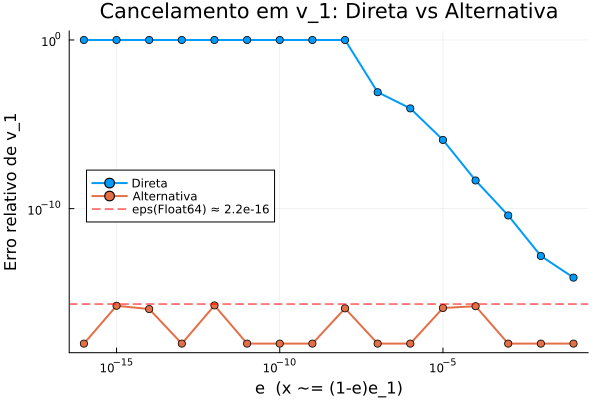

In [ ]:
using Plots

epsilons = [10.0^(-k) for k in 1:16]
erros_direto = Float64[]
erros_alt = Float64[]

for e in epsilons
    x    = [1 - e, e/sqrt(2), e/sqrt(2)]
    nrmx = norm(x)
    
    v1_direto = x[1] - nrmx
    nrmy2 = x[2]^2 + x[3]^2
    v1_alt    = -nrmy2 / (x[1] + nrmx)
    
    x_big = BigFloat.(x)
    v1_exato = x_big[1] - norm(x_big)
    
    err_d = abs(v1_direto - Float64(v1_exato)) / abs(Float64(v1_exato))
    err_a = abs(v1_alt - Float64(v1_exato)) / abs(Float64(v1_exato))
    
    # max() evita que o erro seja exatamente 0.0 e quebre a escala log10
    push!(erros_direto, max(err_d, 1e-18))
    push!(erros_alt, max(err_a, 1e-18))
end

plot(epsilons, erros_direto,
     xscale=:log10, yscale=:log10,
     xlabel="e  (x ~= (1-e)e_1)",
     ylabel="Erro relativo de v_1",
     title="Cancelamento em v_1 (Direta vs Alternativa)",
     label="Direta",
     marker=:circle, lw=2, legend=:left)

plot!(epsilons, erros_alt,
      label="Alternativa",
      marker=:circle, lw=2)

# Linha de referência: eps Float64
hline!([eps(Float64)], linestyle=:dash, color=:red, label="eps(Float64) ≈ 2.2e-16")

O gráfico acima confirma que, à medida que $\epsilon \to 0$ (i.e., $x \to e_1$), o erro relativo de $v_1$ calculado diretamente cresce até a ordem da precisão da máquina (100% de erro). Além disso, a fórmula alternativa $v_1 = -\|y\|^2/(x_1 + \|x\|)$ não sofre esse problema como podemos ver também.